# Dogs vs Cats Image Classification using SVM

## Objective
To classify cat and dog images using a Support Vector Machine (SVM) classifier.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import os

os.chdir(r"C:\Users\D.Gayathri\OneDrive\Documents\SCT_ML_3")

print(os.getcwd())
print(os.listdir())

C:\Users\D.Gayathri\OneDrive\Documents\SCT_ML_3
['cats', 'dogs']


In [4]:
X = []
y = []

image_size = 64

cat_path = "cats"
dog_path = "dogs"


for file in os.listdir(cat_path):

    img_path = os.path.join(cat_path, file)

    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (image_size, image_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        X.append(img.flatten())
        y.append(0)


for file in os.listdir(dog_path):

    img_path = os.path.join(dog_path, file)

    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (image_size, image_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        X.append(img.flatten())
        y.append(1)


print("Images Loaded Successfully!")
print("Total Images:", len(X))

Images Loaded Successfully!
Total Images: 8005


In [5]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8005, 4096)
y shape: (8005,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6404, 4096)
Testing data: (1601, 4096)


In [7]:
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

print(X_train_small.shape)



(2000, 4096)


In [8]:
from sklearn.svm import SVC

svm_model = SVC(kernel="linear")

svm_model.fit(X_train_small, y_train_small)

print("SVM Model Trained Successfully!")

SVM Model Trained Successfully!


In [9]:
y_pred = svm_model.predict(X_test)

print("Prediction completed!")
print(y_pred[:10])

Prediction completed!
[1 0 0 0 1 0 0 1 1 1]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5202998126171143


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.54      0.53       819
           1       0.51      0.50      0.51       782

    accuracy                           0.52      1601
   macro avg       0.52      0.52      0.52      1601
weighted avg       0.52      0.52      0.52      1601



In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[439 380]
 [388 394]]


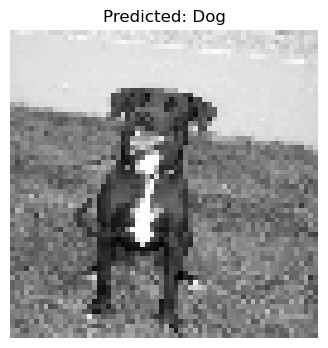

In [13]:
plt.figure(figsize=(4,4))

plt.imshow(X_test[0].reshape(64,64), cmap="gray")

if y_pred[0] == 0:
    plt.title("Predicted: Cat")
else:
    plt.title("Predicted: Dog")

plt.axis("off")
plt.show()

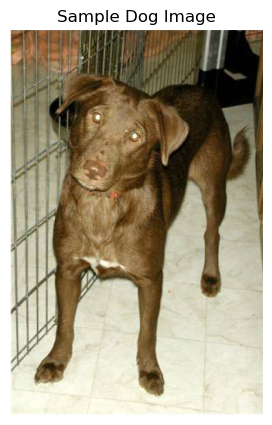

In [14]:
import matplotlib.image as mpimg

img_path = "dogs/" + os.listdir("dogs")[0]

img = mpimg.imread(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Sample Dog Image")
plt.axis("off")
plt.show()

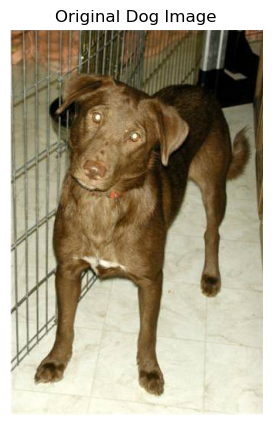

In [15]:
import matplotlib.image as mpimg

img_path = "dogs/" + os.listdir("dogs")[0]

img = mpimg.imread(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Original Dog Image")
plt.axis("off")
plt.show()

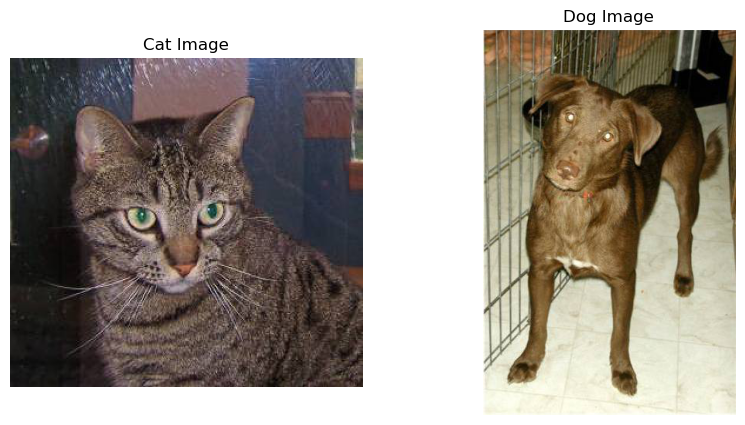

In [17]:
import matplotlib.image as mpimg

# Cat image
cat_img_path = "cats/" + os.listdir("cats")[0]
cat_img = mpimg.imread(cat_img_path)

# Dog image
dog_img_path = "dogs/" + os.listdir("dogs")[0]
dog_img = mpimg.imread(dog_img_path)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cat_img)
plt.title("Cat Image")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(dog_img)
plt.title("Dog Image")
plt.axis("off")

plt.show()

In [19]:
cm = confusion_matrix(y_test, y_pred)

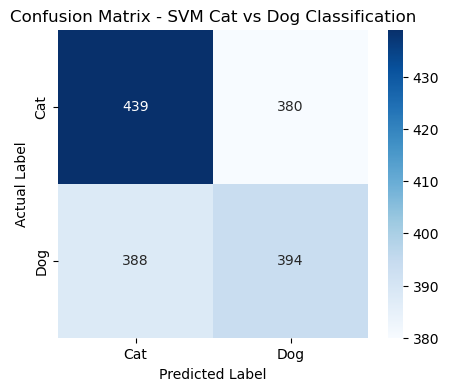

[[439 380]
 [388 394]]


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SVM Cat vs Dog Classification")

plt.show()

print(cm)